# 내일 비가 올지 예측(Rain in Australia)
- 참고 : https://www.kaggle.com/prashant111/extensive-analysis-eda-fe-modelling
- 랜덤 포레스트(Random Forest)

# 관련 라이브러리 import

In [1]:
# 불필요한 경고 출력을 방지
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

# 데이터 준비
- 아래 링크에서 weatherAUS.csv 파일을 다운로드 받기
#### https://www.kaggle.com/jsphyg/weather-dataset-rattle-package



## 데이터 읽기

In [4]:
data_path = "datas_ml/weatherAUS.csv"
df = pd.read_csv(data_path)
print(df.shape)

(145460, 23)


# EDA 수행

## 데이터 형상 파악하기

In [5]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


In [7]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


## 범주형 데이터 통계량 확인

In [8]:
cat_columns = df.select_dtypes(exclude=np.number).columns
cat_columns

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')

In [9]:
print(cat_columns)
df[cat_columns].describe()

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')


,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,145460,145460,135134,134894,141232,142199,142193
unique,3436,49,16,16,16,2,2
top,2013-03-01,Canberra,W,N,SE,No,No
freq,49,3436,9915,11758,10838,110319,110316


## target(y) 데이터 확인

<Axes: xlabel='RainTomorrow', ylabel='count'>

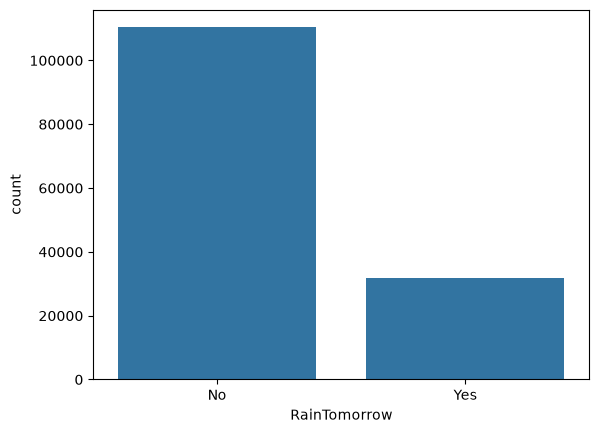

In [10]:
sns.countplot(x="RainTomorrow", data=df)

## 상관 분석(Correlation Analysis) 수행해보기

### 수치형 데이터 확인

In [11]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='str')

In [12]:
temp_df = df[num_cols]
temp_df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7


### 범주형 데이터를 수치형으로 변환
- RainToday, RainTomorrow 컬럼의 데이터를 수치형으로 변환
- 변환하여 수치형 데이터 프레임에 추가

In [13]:
temp_df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1}) #.astype(dtype='int')
temp_df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1}) #.astype(dtype='int')

In [14]:
temp_df.shape

(145460, 18)

In [15]:
temp_df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,0.0,0.0
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,0.0,0.0
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,0.0,0.0
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,0.0,0.0
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0.0,0.0


### 상관관계 계수 확인

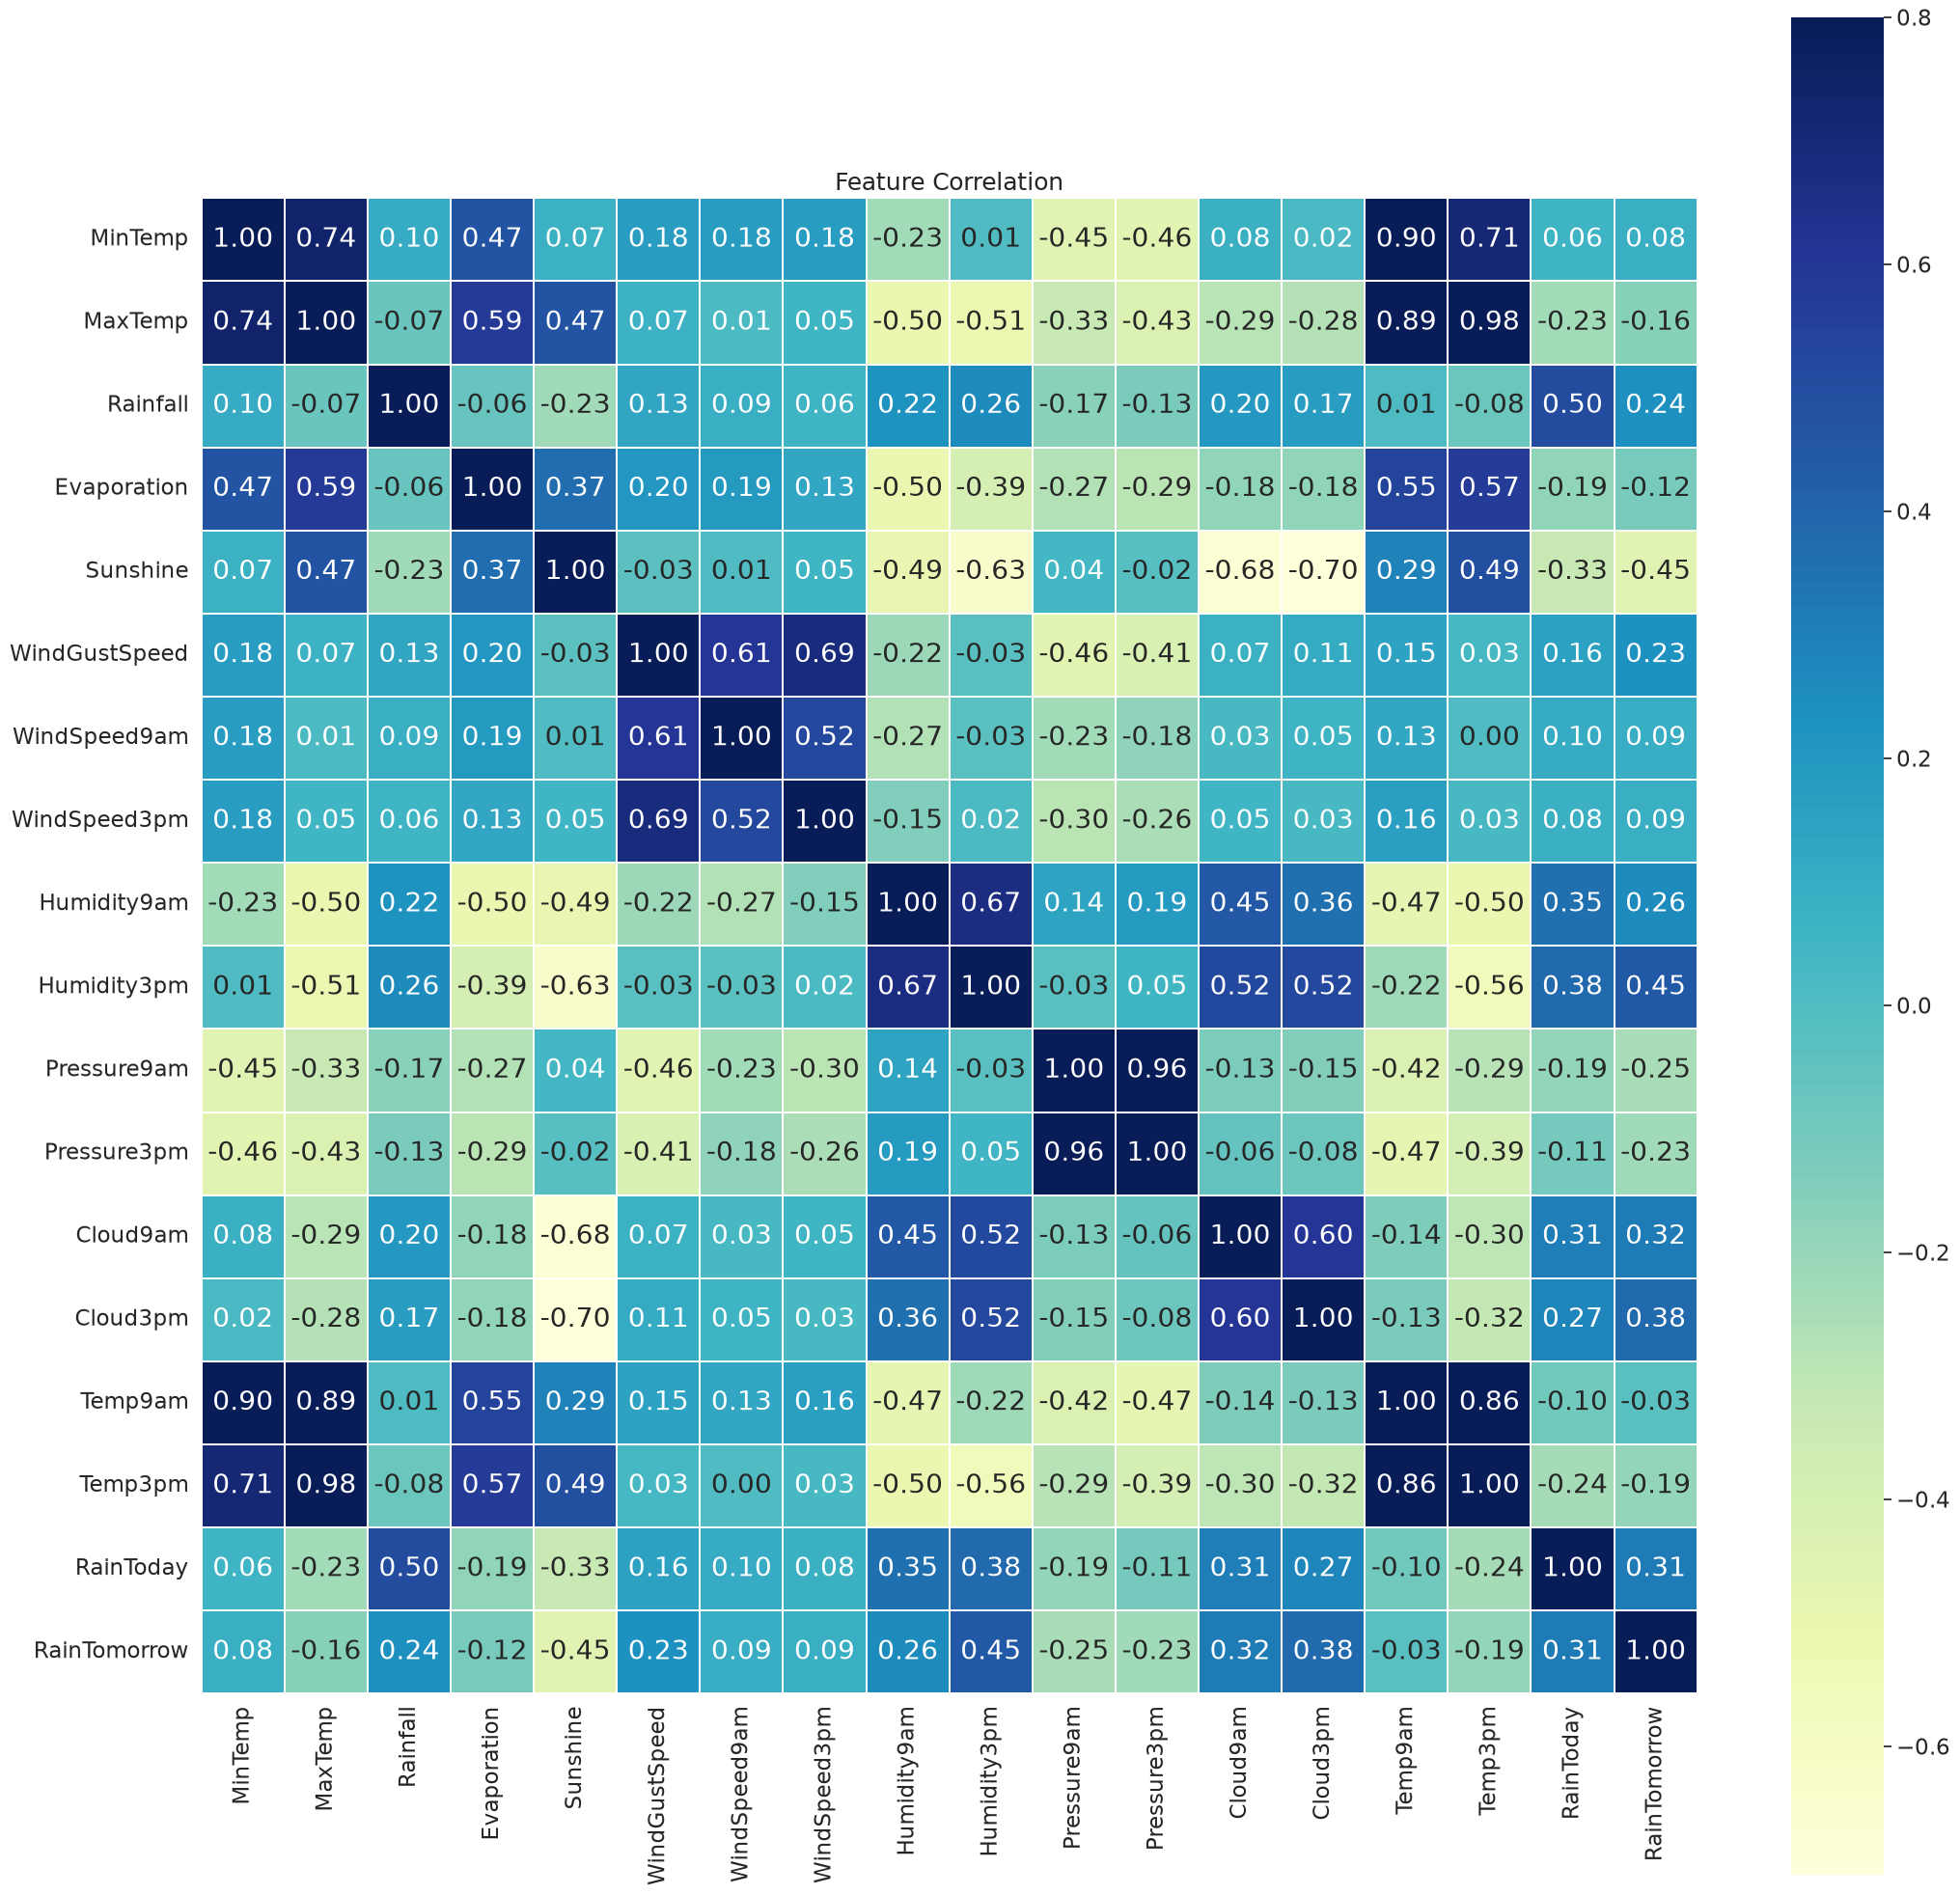

In [16]:
corr = temp_df.corr()
plt.figure(figsize=(25, 25));
sns.set(font_scale=1.5); # plot의 글자크기 설정
sns.heatmap(corr,
            vmax=0.8,
            #vmin=-1,
            linewidths=0.01,
            square=True,
            annot=True,
            fmt = '.2f', # annot의 출력 소숫점 자리 지정
            annot_kws={"size": 20},
            cmap='YlGnBu');
plt.title('Feature Correlation');

# 결측치 처리
## (null값) 확인하기

In [17]:
df.isnull().mean().sort_values()

Date             0.000000
Location         0.000000
MaxTemp          0.008669
MinTemp          0.010209
WindSpeed9am     0.012148
Temp9am          0.012148
Humidity9am      0.018246
WindSpeed3pm     0.021050
RainToday        0.022419
Rainfall         0.022419
RainTomorrow     0.022460
Temp3pm          0.024811
WindDir3pm       0.029066
Humidity3pm      0.030984
WindGustSpeed    0.070555
WindGustDir      0.070989
WindDir9am       0.072639
Pressure3pm      0.103314
Pressure9am      0.103568
Cloud9am         0.384216
Cloud3pm         0.408071
Evaporation      0.431665
Sunshine         0.480098
dtype: float64

## categorical column 확인하기

In [18]:
cat_cols = df.select_dtypes(exclude=np.number).columns
print(cat_columns)

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')


## numerical column 확인하기

In [19]:
num_cols = df.select_dtypes(include=np.number).columns
print(num_cols)

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='str')


# 결측치 개수 확인하기

In [20]:
df[cat_cols].isnull().mean().sort_values()

Date            0.000000
Location        0.000000
RainToday       0.022419
RainTomorrow    0.022460
WindDir3pm      0.029066
WindGustDir     0.070989
WindDir9am      0.072639
dtype: float64

In [21]:
df[num_cols].isnull().mean().sort_values()

MaxTemp          0.008669
MinTemp          0.010209
WindSpeed9am     0.012148
Temp9am          0.012148
Humidity9am      0.018246
WindSpeed3pm     0.021050
Rainfall         0.022419
Temp3pm          0.024811
Humidity3pm      0.030984
WindGustSpeed    0.070555
Pressure3pm      0.103314
Pressure9am      0.103568
Cloud9am         0.384216
Cloud3pm         0.408071
Evaporation      0.431665
Sunshine         0.480098
dtype: float64

## 결측치 채우기
### 수치형 컬럼 결측처리
- numerical value를 가진 column은 중위값(meidan)으로 채우기

In [22]:
#df['Sunshine'].fillna(df['Sunshine'].median())
df['Sunshine'] = df['Sunshine'].fillna(df['Sunshine'].median())

In [23]:
for col in num_cols:
    if df[col].isnull().mean() > 0:
        col_median = df[col].median()
        df[col] = df[col].fillna(col_median)

### 범주형 컬럼 결측처리 
- null이 있는 범주형 컬럼 확인

In [24]:
for col in cat_cols:
    if df[col].isnull().mean() > 0:
        print(col, (df[col].isnull().mean()))

WindGustDir 0.0709885879279527
WindDir9am 0.07263852605527293
WindDir3pm 0.02906641000962464
RainToday 0.022418534304963565
RainTomorrow 0.02245978275814657


In [ ]:
# WindGustDir 컬럼에서 가장 많이 등장한 값(최빈값) 확인
df['WindGustDir'].mode()[0]

In [ ]:
# 방법1
# categorical(범주형) 컬럼은 평균/중앙값을 구할 수 없으므로 최빈값(mode)으로 결측치를 채움
# RainTomorrow 는 target 이기 때문에 결측치 처리하지 않음.(일반적인 선택)
df['WindGustDir'] = df['WindGustDir'].fillna(df['WindGustDir'].mode()[0])  # 가장 흔한 풍향으로 채움
df['WindDir9am'] = df['WindDir9am'].fillna(df['WindDir9am'].mode()[0])    # 가장 흔한 풍향으로 채움
df['WindDir3pm'] = df['WindDir3pm'].fillna(df['WindDir3pm'].mode()[0])    # 가장 흔한 풍향으로 채움
df['RainToday'] = df['RainToday'].fillna(df['RainToday'].mode()[0])      # 가장 흔한 값(No/Yes)으로 채움

In [26]:
cat_cols= list(cat_cols)
cat_cols

['Date',
 'Location',
 'WindGustDir',
 'WindDir9am',
 'WindDir3pm',
 'RainToday',
 'RainTomorrow']

In [27]:
cat_cols.remove('RainTomorrow')
cat_cols

['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

In [ ]:
# 방법2
# 방법1처럼 컬럼명을 일일이 나열하지 않고, cat_cols 리스트를 순회하면서
# 결측치가 있는 범주형 컬럼만 최빈값(mode)으로 자동 처리하는 방식
# (cat_cols에서 RainTomorrow는 이미 제거했으므로 target은 자동으로 제외됨)
# 방법1에서 이미 결측치를 채웠기 때문에 여기서는 실행하지 않고 주석 처리해 둠
# for col in cat_cols:
#     if df[col].isnull().mean() > 0:
#         df[col] = df[col].fillna(df[col].mode()[0])

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    145460 non-null  float64
 6   Sunshine       145460 non-null  float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  145460 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   145460 non-null  float64
 12  WindSpeed3pm   145460 non-null  float64
 13  Humidity9am    145460 non-null  float64
 14  Humidity3pm    145460 non-null  float64
 15  Pressure9am    145460 non-null  float64
 16  Pressure3pm    145460 non-null  float64
 17  Cloud9am       145460 non-null  float64


In [29]:
df.isnull().sum()

Date                 0
Location             0
MinTemp              0
MaxTemp              0
Rainfall             0
Evaporation          0
Sunshine             0
WindGustDir      10326
WindGustSpeed        0
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am         0
WindSpeed3pm         0
Humidity9am          0
Humidity3pm          0
Pressure9am          0
Pressure3pm          0
Cloud9am             0
Cloud3pm             0
Temp9am              0
Temp3pm              0
RainToday         3261
RainTomorrow      3267
dtype: int64

## 필요 없는 컬럼 삭제 

In [30]:
df = df.drop(['Date'], axis=1)

In [31]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.9,0.6,4.8,8.4,W,44.0,W,WNW,...,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,4.8,8.4,WNW,44.0,NNW,WSW,...,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,4.8,8.4,WSW,46.0,W,WSW,...,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,4.8,8.4,NE,24.0,SE,E,...,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,4.8,8.4,W,41.0,ENE,NW,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [32]:
df.isnull().mean().sort_values()

Location         0.000000
MinTemp          0.000000
MaxTemp          0.000000
Rainfall         0.000000
Evaporation      0.000000
Sunshine         0.000000
WindGustSpeed    0.000000
WindSpeed3pm     0.000000
Pressure9am      0.000000
WindSpeed9am     0.000000
Humidity3pm      0.000000
Humidity9am      0.000000
Pressure3pm      0.000000
Temp9am          0.000000
Cloud3pm         0.000000
Cloud9am         0.000000
Temp3pm          0.000000
RainToday        0.022419
RainTomorrow     0.022460
WindDir3pm       0.029066
WindGustDir      0.070989
WindDir9am       0.072639
dtype: float64

## target의 null 값처리
- RainTomorrow는 target이기 때문에 nan은 drop으로 처리
- RainTomorrow 예측 값이므로 null 값 삭제함

In [33]:
df.shape

(145460, 22)

In [34]:
df.shape

(145460, 22)

In [35]:
df.isnull().sum()

Location             0
MinTemp              0
MaxTemp              0
Rainfall             0
Evaporation          0
Sunshine             0
WindGustDir      10326
WindGustSpeed        0
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am         0
WindSpeed3pm         0
Humidity9am          0
Humidity3pm          0
Pressure9am          0
Pressure3pm          0
Cloud9am             0
Cloud3pm             0
Temp9am              0
Temp3pm              0
RainToday         3261
RainTomorrow      3267
dtype: int64

In [36]:
df = df.dropna(subset=['RainTomorrow'])
df.info()

<class 'pandas.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 22 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Location       142193 non-null  str    
 1   MinTemp        142193 non-null  float64
 2   MaxTemp        142193 non-null  float64
 3   Rainfall       142193 non-null  float64
 4   Evaporation    142193 non-null  float64
 5   Sunshine       142193 non-null  float64
 6   WindGustDir    132863 non-null  str    
 7   WindGustSpeed  142193 non-null  float64
 8   WindDir9am     132180 non-null  str    
 9   WindDir3pm     138415 non-null  str    
 10  WindSpeed9am   142193 non-null  float64
 11  WindSpeed3pm   142193 non-null  float64
 12  Humidity9am    142193 non-null  float64
 13  Humidity3pm    142193 non-null  float64
 14  Pressure9am    142193 non-null  float64
 15  Pressure3pm    142193 non-null  float64
 16  Cloud9am       142193 non-null  float64
 17  Cloud3pm       142193 non-null  float64
 18  

In [37]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.9,0.6,4.8,8.4,W,44.0,W,WNW,...,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,4.8,8.4,WNW,44.0,NNW,WSW,...,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,4.8,8.4,WSW,46.0,W,WSW,...,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,4.8,8.4,NE,24.0,SE,E,...,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,4.8,8.4,W,41.0,ENE,NW,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


# Yes/No 값에 대한 변환

In [38]:
df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

print(df['RainToday'].dtype, df['RainTomorrow'].dtype)

float64 int64


## categorical value에 one-hot encoding 적용하기

In [ ]:
# 원-핫 인코딩을 적용할 범주형 컬럼 목록 확인
cat_cols

In [ ]:
# 범주형 컬럼을 원-핫 인코딩(one-hot encoding) 적용
# pd.get_dummies()는 각 범주형 컬럼의 고유값마다 0/1로 이루어진 새 컬럼을 만들어줌
# 예) WindGustDir의 'W', 'N' 등 16개 방향값 -> WindGustDir_W, WindGustDir_N 등 16개 컬럼으로 분리됨
# Date는 이미 삭제했고, RainToday/RainTomorrow는 앞에서 0/1로 매핑했으므로 인코딩 대상에서 제외
df = pd.get_dummies(df, columns = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm'])

In [ ]:
# 원-핫 인코딩 적용 후 데이터 형태 확인
df.head()

In [ ]:
# 인코딩 후 전체 컬럼 수 확인 (범주형 컬럼들이 여러 개의 0/1 컬럼으로 늘어남)
df.shape

# ML을 위한 학습, 테스트 데이터 준비

In [44]:
# [문제] 특징 변수와 타겟 변수 분할 하기
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

In [45]:
X.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,13.4,22.9,0.6,4.8,8.4,44.0,20.0,24.0,71.0,22.0,...,False,False,False,False,False,False,False,False,True,False
1,7.4,25.1,0.0,4.8,8.4,44.0,4.0,22.0,44.0,25.0,...,False,False,False,False,False,False,False,False,False,True
2,12.9,25.7,0.0,4.8,8.4,46.0,19.0,26.0,38.0,30.0,...,False,False,False,False,False,False,False,False,False,True
3,9.2,28.0,0.0,4.8,8.4,24.0,11.0,9.0,45.0,16.0,...,False,False,False,False,False,False,False,False,False,False
4,17.5,32.3,1.0,4.8,8.4,41.0,7.0,20.0,82.0,33.0,...,False,True,False,False,False,False,False,False,False,False


In [46]:
y[:5]

0    0
1    0
2    0
3    0
4    0
Name: RainTomorrow, dtype: int64

In [47]:
y.value_counts()

RainTomorrow
0    110316
1     31877
Name: count, dtype: int64

In [48]:
# [문제]  학습, 테스트 데이터 분할 하기
# 학습 : 테스트 = 7 : 3 
# 불균형 데이터 이므로 stratify = y 로 설정
# 재현을 위해 seed 값은 2026 설정


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify = y, random_state=6 )

In [49]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((99535, 114), (42658, 114), (99535,), (42658,))

# ML 모델 학습

## 결정 트리(Decision Tree)로 내일 비가 올지 안올지 예측해보기

In [50]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
# [문제] 결정 트리 모델 학습 및 예측 수행
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)

y_pred = dt_clf.predict(X_test)

In [51]:
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(42658,))

In [52]:
# [문제] 결정 트리 정확도 출력
score = accuracy_score(y_test, y_pred)
print('결정 트리(Decision Tree) Accuracy :',score)

결정 트리(Decision Tree) Accuracy : 0.7903792957944582


### [문제] 정확도, 정밀도, 재현율, f1-스코아를 값을 확인해 보세요.

In [53]:
from sklearn.metrics import classification_report
# [문제] classification_report() 결과 출력

# y_test: 실제 라벨, y_pred: 모델 예측 라벨
print("정확도:", accuracy_score(y_test, y_pred))
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(y_test, y_pred))

정확도: 0.7903792957944582

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.87      0.86      0.86     33095
           1       0.53      0.55      0.54      9563

    accuracy                           0.79     42658
   macro avg       0.70      0.70      0.70     42658
weighted avg       0.79      0.79      0.79     42658



In [55]:
# [문제] roc_auc_score 출력, 소숫점 첫째자리까지만 출력
from sklearn.metrics import roc_auc_score

print(round(roc_auc_score(y_test, y_pred),1))

0.7


## 랜덤 포레스트(Random Forest)로  
- 참고 : https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- DT default = 100개를 만들어서 학습을 시킴

In [56]:
from sklearn.ensemble import RandomForestClassifier
# [문제] RandomForestClassifier 분류 모델 학습 및 예측 수행

rf_clf = RandomForestClassifier()

rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

In [57]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(42658,))

In [59]:
# 정확도 평가
score = accuracy_score(y_test, y_pred)
print('랜덤 포레스트(Random Forest) Accuracy :', score)

랜덤 포레스트(Random Forest) Accuracy : 0.8589010267710628


In [ ]:
from sklearn.metrics import classification_report
# classification_report() 결과 출력
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(y_test, y_pred))


[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     33095
           1       0.78      0.51      0.62      9563

    accuracy                           0.86     42658
   macro avg       0.83      0.74      0.77     42658
weighted avg       0.85      0.86      0.85     42658



In [61]:
# [문제] roc_auc_score 출력, 소숫점 둘째자리까지만 출력
from sklearn.metrics import roc_auc_score

print(round(roc_auc_score(y_test, y_pred),2))

0.74


# XGBoost 분류기

In [63]:
from xgboost import XGBClassifier
# [문제] xgboost 학습 수행 및 예측

xgb_clf = XGBClassifier()
xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)


In [64]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(42658,))

In [66]:
from sklearn.metrics import classification_report
# [문제] classification_report() 결과 출력
# y_test: 실제 라벨, y_pred: 모델 예측 라벨
print("정확도:", accuracy_score(y_test, y_pred))
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(y_test, y_pred))

정확도: 0.8608467344929439

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     33095
           1       0.75      0.57      0.65      9563

    accuracy                           0.86     42658
   macro avg       0.82      0.76      0.78     42658
weighted avg       0.85      0.86      0.85     42658



In [67]:
# [문제] roc_auc_score 출력, 소숫점 둘째자리까지만 출력
from sklearn.metrics import roc_auc_score

print(round(roc_auc_score(y_test, y_pred),2))

0.76
